In [9]:
!pip install nltk

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [11]:
data = {
    'review': [
        'I absolutely loved this movie! The story was amazing and the acting was excellent.',
        'This was a fantastic show. I really enjoyed every episode.',
        'The movie was okay, but nothing special.',
        'I did not enjoy this movie. The story was boring.',
        'Terrible movie. I wasted my time watching it.',
        'The acting was great and the ending was wonderful.',
        'It was an average movie with some good moments.',
        'I hated the storyline and the characters were disappointing.',
        'A brilliant and entertaining film. Highly recommended!',
        'The show was dull and too long.'
    ]
}

reviews_df = pd.DataFrame(data)

reviews_df.head()

,review
0,I absolutely loved this movie! The story was a...
1,This was a fantastic show. I really enjoyed ev...
2,"The movie was okay, but nothing special."
3,I did not enjoy this movie. The story was boring.
4,Terrible movie. I wasted my time watching it.


In [12]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

In [13]:
reviews_df['compound'] = reviews_df['review'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

def get_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

reviews_df['sentiment'] = reviews_df['compound'].apply(get_sentiment)

reviews_df

,review,compound,sentiment
0,I absolutely loved this movie! The story was a...,0.9183,Positive
1,This was a fantastic show. I really enjoyed ev...,0.8016,Positive
2,"The movie was okay, but nothing special.",-0.3479,Negative
3,I did not enjoy this movie. The story was boring.,-0.6031,Negative
4,Terrible movie. I wasted my time watching it.,-0.7430,Negative
5,The acting was great and the ending was wonder...,0.8316,Positive
6,It was an average movie with some good moments.,0.4404,Positive
7,I hated the storyline and the characters were ...,-0.8126,Negative
8,A brilliant and entertaining film. Highly reco...,0.8436,Positive
9,The show was dull and too long.,-0.4019,Negative


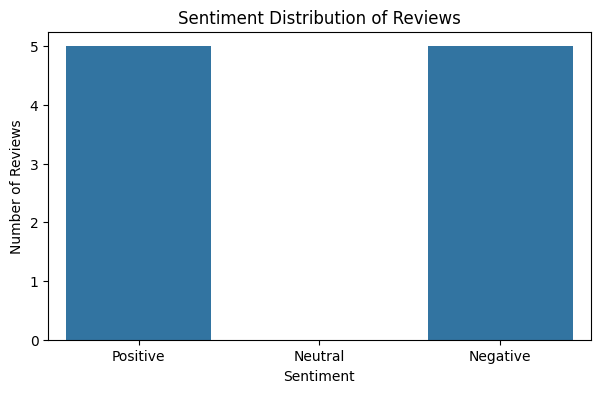

In [14]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=reviews_df,
    x='sentiment',
    order=['Positive', 'Neutral', 'Negative']
)

plt.title('Sentiment Distribution of Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

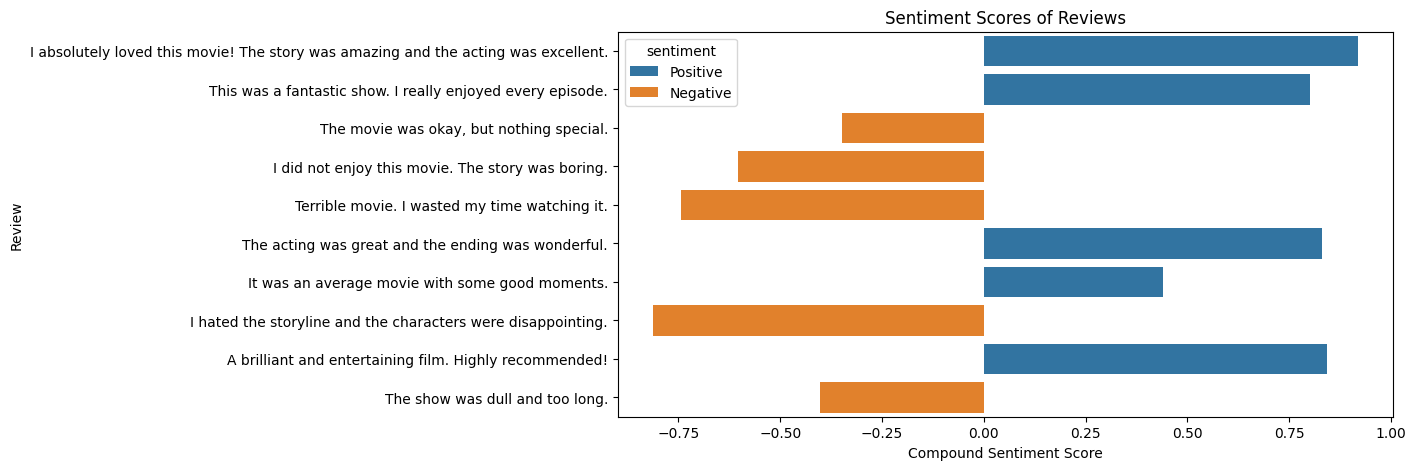

In [15]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=reviews_df,
    x='compound',
    y='review',
    hue='sentiment',
    dodge=False
)

plt.title('Sentiment Scores of Reviews')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Review')
plt.show()

## Key Insights

1. The reviews were classified into Positive, Neutral, and Negative sentiments.

2. Positive reviews indicate satisfaction with the movie or show.

3. Negative reviews indicate dissatisfaction with the content.

4. Neutral reviews show mixed or average opinions.

5. VADER sentiment analysis helped identify the overall sentiment of the sample reviews.

In [16]:
print("Sentiment Counts:")
print(reviews_df['sentiment'].value_counts())

Sentiment Counts:
sentiment
Positive    5
Negative    5
Name: count, dtype: int64
